In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from helper import *
from plots import *
from timeit import default_timer as timer
import random
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
from skopt.space import Integer, Real, Categorical
from skopt import BayesSearchCV

In [75]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [76]:
data = pd.read_csv('adult.csv')

In [77]:
df_preprocessed = data.copy()
df_preprocessed = df_preprocessed.drop(['fnlwgt', 'educational-num'], axis=1)
df_preprocessed = df_preprocessed.replace('?', np.nan)
df_preprocessed['income'] = np.where(df_preprocessed['income'] == '>50K', 1, 0)
df_preprocessed['Own-child'] = (df_preprocessed['relationship'] == 'Own-child').astype(int)

df_preprocessed.head()

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,Own-child
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,1
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,0
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,0
4,18,NaN,Some-college,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0,1


In [78]:
education_map = {
    'Preschool': 'School',
    '1st-4th':   'School',
    '5th-6th':   'School',
    '7th-8th':   'School',
    '9th':       'School',
    '10th':      'School',
    '11th':      'School',
    '12th':      'School',

    'HS-grad':      'HS-grad',
    'Some-college': 'Some-college',

    'Assoc-voc':  'Assoc',
    'Assoc-acdm': 'Assoc',

    'Bachelors':   'Bachelors',

    'Masters':     'Post-grad',
    'Prof-school': 'Post-grad',
    'Doctorate':   'Post-grad',
}

country_map = {
    'United-States': 'US',
    'Canada': 'Anglo',
    'England': 'Anglo',
    'Australia': 'Anglo',
    'Ireland': 'Anglo',
    'Scotland': 'Anglo',

    'Mexico': 'LatAm',
    'Puerto-Rico': 'LatAm',
    'Cuba': 'LatAm',
    'Jamaica': 'LatAm',
    'Dominican-Republic': 'LatAm',
    'El-Salvador': 'LatAm',
    'Guatemala': 'LatAm',
    'Columbia': 'LatAm',
    'Haiti': 'LatAm',
    'Honduras': 'LatAm',
    'Nicaragua': 'LatAm',
    'Peru': 'LatAm',
    'Trinadad&Tobago': 'LatAm',
    'Ecuador': 'LatAm',

    'Germany': 'Europe',
    'Italy': 'Europe',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'France': 'Europe',
    'Greece': 'Europe',
    'Holand-Netherlands': 'Europe',
    'Hungary': 'Europe',
    'Yugoslavia': 'Europe',

    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    'Taiwan': 'Asia',
    'Iran': 'Asia',
    'Thailand': 'Asia',
    'Hong': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',
}


marital_map = {
    'Married-civ-spouse':    'Married',
    'Married-AF-spouse':     'Married',

    'Married-spouse-absent': 'Married-absent',

    'Divorced':  'Was married',
    'Separated': 'Was married',
    'Widowed':   'Was married',

    'Never-married': 'Never married',
}


race_map = {
    'White':               'White',
    'Black':               'Black',
    'Asian-Pac-Islander':  'Asian',
    'Amer-Indian-Eskimo':  'Other',
    'Other':               'Other',
}

workclass_map = {
    'Private':          'Private',
    'Self-emp-inc':     'Entrepreneur',
    'Self-emp-not-inc': 'Self-emp',       
    'Federal-gov':      'Gov',
    'Local-gov':        'Gov',
    'State-gov':        'Gov',
    'Without-pay':      'No-income',
    'Never-worked':     'No-income',
}

occupation_map = {
    'Prof-specialty':  'High white-collar',
    'Exec-managerial': 'High white-collar',

    'Adm-clerical':    'Low white-collar',
    'Tech-support':    'Low white-collar',

    'Sales':           'Sales',

    'Other-service':   'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',

    'Craft-repair':      'Blue-collar',
    'Machine-op-inspct': 'Blue-collar',
    'Transport-moving':  'Blue-collar',
    'Handlers-cleaners': 'Blue-collar',

    'Farming-fishing': 'Other',
    'Armed-Forces':    'Other',
}




In [79]:
df_preprocessed['education_group'] = df_preprocessed['education'].map(education_map)
df_preprocessed['country_group'] = df_preprocessed['native-country'].map(country_map)
df_preprocessed['race_group'] = df_preprocessed['race'].map(race_map)
df_preprocessed['occupation_group'] = df_preprocessed['occupation'].map(occupation_map)
df_preprocessed['marital_group'] = df_preprocessed['marital-status'].map(marital_map)
df_preprocessed['workclass_group'] = df_preprocessed['workclass'].map(workclass_map)

df_preprocessed = df_preprocessed.drop(['workclass', 'marital-status', 'race', 'occupation', 'native-country', 'education', 'relationship'], axis=1)
df_preprocessed.head()

,age,gender,capital-gain,capital-loss,hours-per-week,income,Own-child,education_group,country_group,race_group,occupation_group,marital_group,workclass_group
0,25,Male,0,0,40,0,1,School,US,Black,Blue-collar,Never married,Private
1,38,Male,0,0,50,0,0,HS-grad,US,White,Other,Married,Private
2,28,Male,0,0,40,1,0,Assoc,US,White,Service,Married,Gov
3,44,Male,7688,0,40,1,0,Some-college,US,Black,Blue-collar,Married,Private
4,18,Female,0,0,30,0,1,Some-college,US,White,NaN,Never married,NaN


In [80]:
X, y = divide_data(df_preprocessed, 'income')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [81]:
categorical_cols_onehot = ['gender', 'country_group', 'marital_group', 'race_group', 'workclass_group', 'occupation_group']
categorical_cols_ordered = ['education_group']
category_orders = [
    ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Post-grad'], # education_group
]
most_frequent_cat_cols = ['workclass_group', 'occupation_group', 'country_group']

preprocessor = Pipeline([
    ('nan_remover', ColumnTransformer(
        [
            ('most_frequent_cat', SimpleImputer(strategy='most_frequent'), most_frequent_cat_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )),
    ('transformations', ColumnTransformer(
        [('ordinal', OrdinalEncoder(
            categories=category_orders, 
            handle_unknown='use_encoded_value',
            unknown_value=-1,),
            categorical_cols_ordered),

         ('onehot', OneHotEncoder(
             drop='first',
             handle_unknown='ignore',
             sparse_output=False, 
         ), 
            categorical_cols_onehot)],
        remainder='passthrough',
        verbose_feature_names_out=False
    ))
])
preprocessor.set_output(transform="pandas")

,steps,"[('nan_remover', ...), ('transformations', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('most_frequent_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"

In [82]:
base_model = ('LGBMClassifier', LGBMClassifier(random_state=SEED))
preprocessor.steps.append(base_model)
pipeline = preprocessor

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685


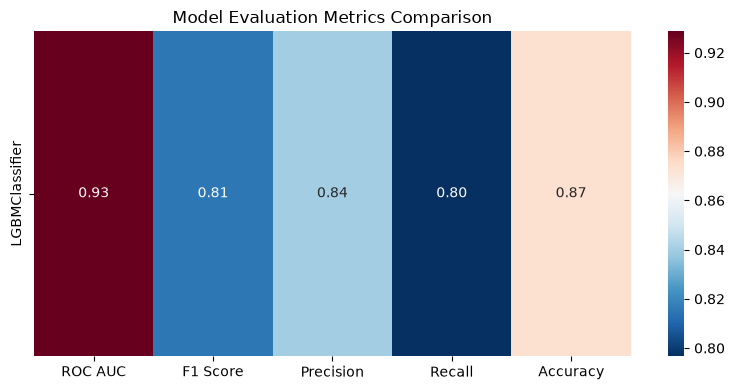

In [83]:
initial_metrics = train_evaluate_models(
    models=[('LGBMClassifier', pipeline)],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    seed=SEED
)

In [84]:
initial_metrics

,ROC AUC,F1 Score,Precision,Recall,Accuracy
LGBMClassifier,0.928708,0.814917,0.840025,0.796792,0.873477


In [ ]:
base_model[1].get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [86]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Grid Search

In [87]:
param_grid = {
    "LGBMClassifier__num_leaves":        [15, 31, 63],       # сложность дерева
    "LGBMClassifier__max_depth":         [8, 10, 15],        # глубина дерева
    "LGBMClassifier__n_estimators":      [100, 200, 500],   # деревьев
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    verbose=3
)

In [88]:
grid_search_start = timer()
grid_search.fit(X_train, y_train)
grid_search_end = timer()

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7479, number of negative: 23779
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 31258, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239267 -> initscore=-1.156704
[LightGBM] [Info] Start training from score -1.156704
[CV 1/5] END LGBMClassifier__max_depth=8, LGBMClassifier__n_estimators=100, LGBMClassifier__num_leaves=15;, score=0.928 total time=   0.5s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7479, number of negative: 23779
[LightGBM] [I

In [89]:
print(f"Total time: {grid_search_end - grid_search_start:.2f} seconds")

Total time: 60.46 seconds


/home/bibeda/DSpractice/plots.py:388: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


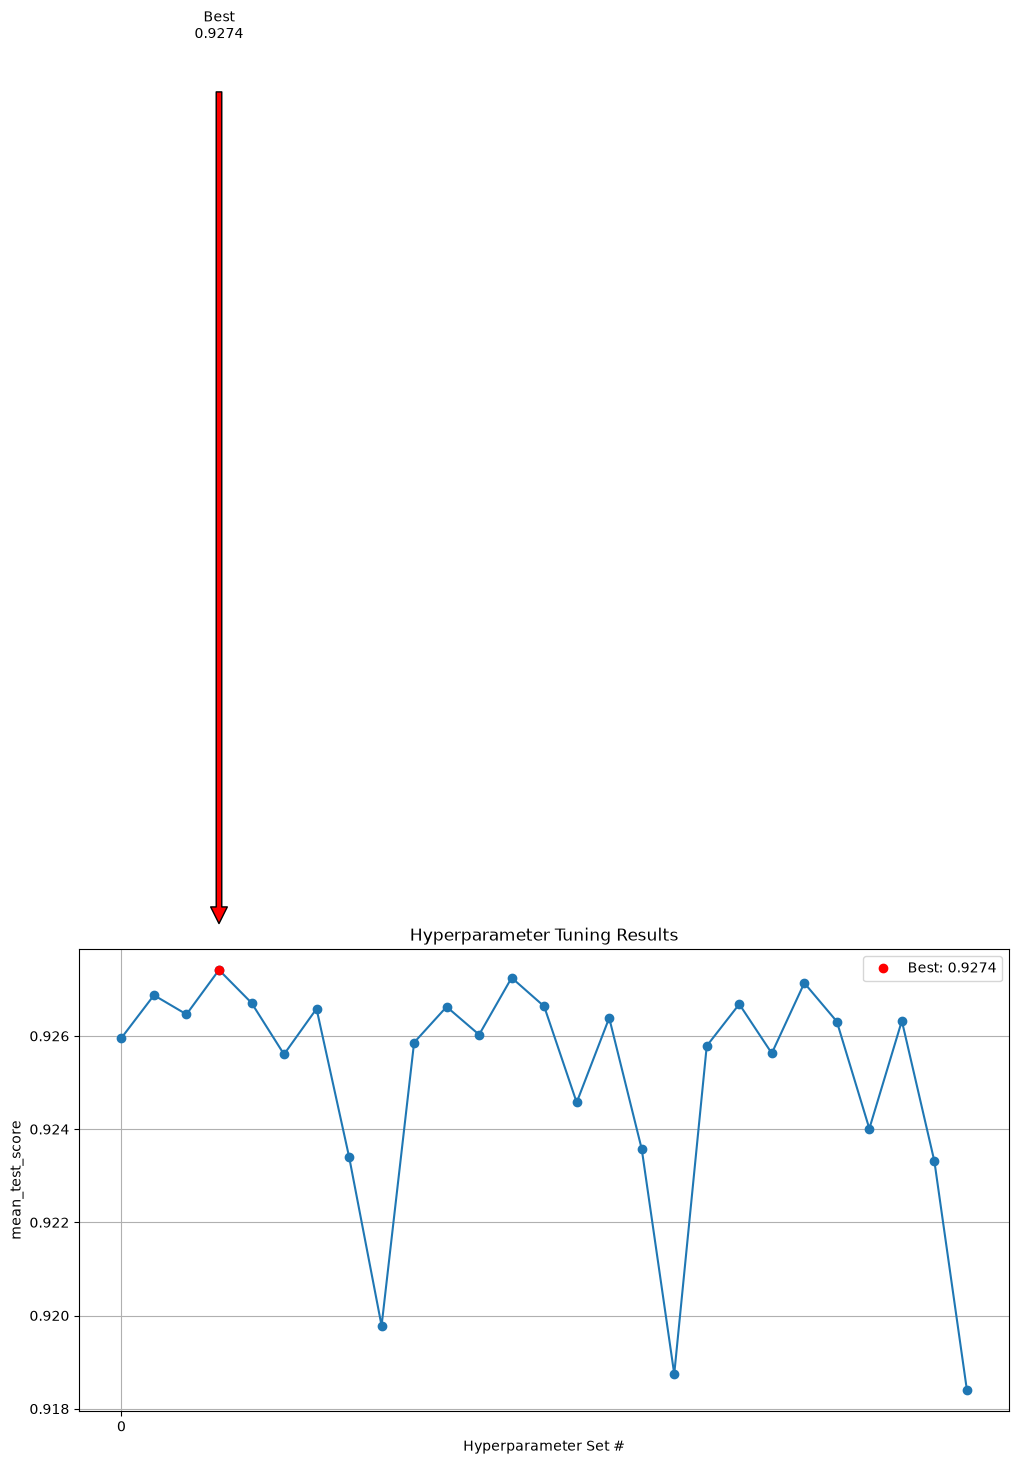

In [90]:
data = plot_hyperparam_search_results(grid_search.cv_results_, xtick_step=100)

In [91]:
grid_search.best_params_

{'LGBMClassifier__max_depth': 8,
 'LGBMClassifier__n_estimators': 200,
 'LGBMClassifier__num_leaves': 15}

In [92]:
grid_search_best_model = grid_search.best_estimator_

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685


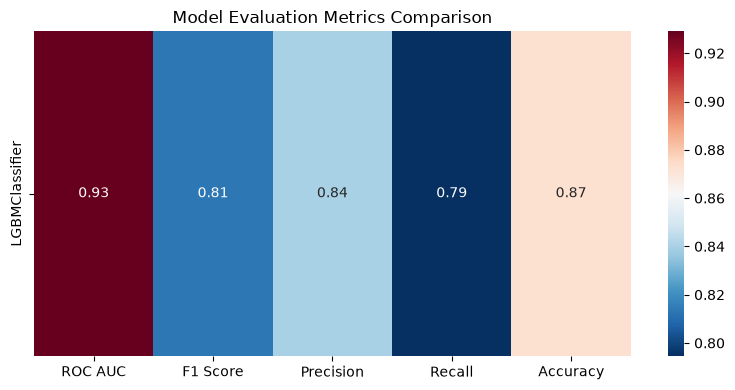

In [93]:
grid_search_metrics = train_evaluate_models(
    models=[('LGBMClassifier', grid_search_best_model)],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    seed=SEED
)

In [94]:
grid_search_metrics

,ROC AUC,F1 Score,Precision,Recall,Accuracy
LGBMClassifier,0.929078,0.813452,0.839934,0.79463,0.872863


(<Figure size 800x400 with 2 Axes>,
                  ROC AUC  F1 Score  Precision    Recall  Accuracy
 LGBMClassifier  0.000371 -0.001465  -0.000091 -0.002163 -0.000614)

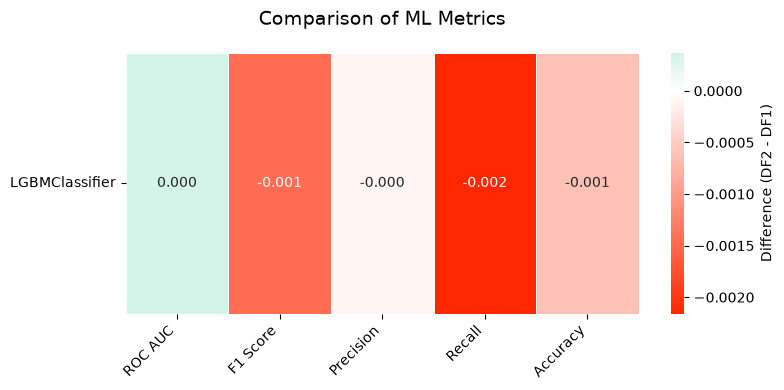

In [95]:
compare_metrics_heatmap(initial_metrics, grid_search_metrics)

# Random Search

In [102]:
param_dist = {
    "LGBMClassifier__num_leaves": sp_randint(15, 32),
    "LGBMClassifier__max_depth": [-1, 8, 12, 16],
    "LGBMClassifier__reg_alpha":         [0.01, 0.1, 1.0],
    "LGBMClassifier__reg_lambda":        [0.01, 0.1, 1.0],
    "LGBMClassifier__learning_rate": sp_uniform(0.01, 0.1),
    "LGBMClassifier__n_estimators": [100, 200, 500, 1000],
}


In [103]:
randomized_search = RandomizedSearchCV(
    random_state=SEED,
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    verbose=3
)

In [104]:
randomized_search_start = timer()
randomized_search.fit(X_train, y_train)
randomized_search_end = timer()

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7479, number of negative: 23779
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 31258, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239267 -> initscore=-1.156704
[LightGBM] [Info] Start training from score -1.156704
[CV 1/5] END LGBMClassifier__learning_rate=0.047454011884736254, LGBMClassifier__max_depth=-1, LGBMClassifier__n_estimators=500, LGBMClassifier__num_leaves=25, LGBMClassifier__reg_alpha=0.01, LGBMClassifier__reg_lambda=0.01;, score=0.930 total time=   1.2s
[LightGBM] [Warning] Found whitespace in fea

In [105]:
print(f"Total time: {randomized_search_end - randomized_search_start:.2f} seconds")

Total time: 346.38 seconds


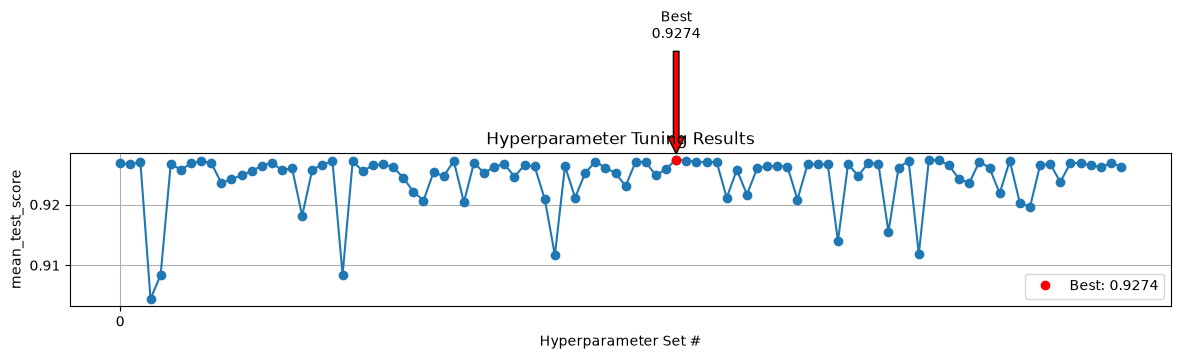

In [106]:
data = plot_hyperparam_search_results(randomized_search.cv_results_, xtick_step=100)

In [107]:
randomized_search.best_params_

{'LGBMClassifier__learning_rate': np.float64(0.10539285770025873),
 'LGBMClassifier__max_depth': -1,
 'LGBMClassifier__n_estimators': 200,
 'LGBMClassifier__num_leaves': 17,
 'LGBMClassifier__reg_alpha': 0.01,
 'LGBMClassifier__reg_lambda': 0.01}

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685


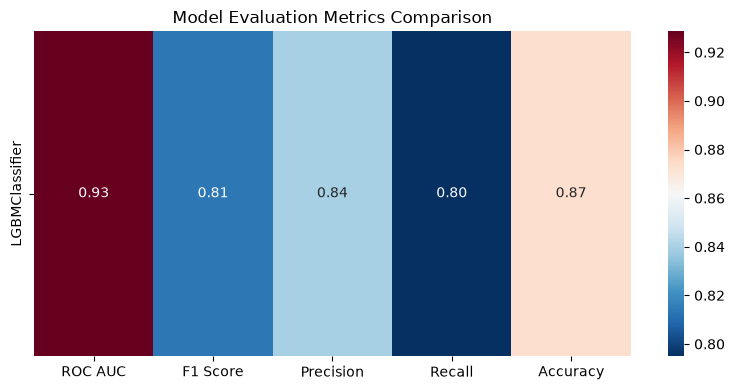

In [108]:
randomized_search_metrics = train_evaluate_models(
    models=[('LGBMClassifier', randomized_search.best_estimator_)],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    seed=SEED
)

In [109]:
randomized_search_metrics

,ROC AUC,F1 Score,Precision,Recall,Accuracy
LGBMClassifier,0.928617,0.813642,0.839639,0.795069,0.872863


(<Figure size 800x400 with 2 Axes>,
                  ROC AUC  F1 Score  Precision    Recall  Accuracy
 LGBMClassifier -0.000091 -0.001276  -0.000386 -0.001723 -0.000614)

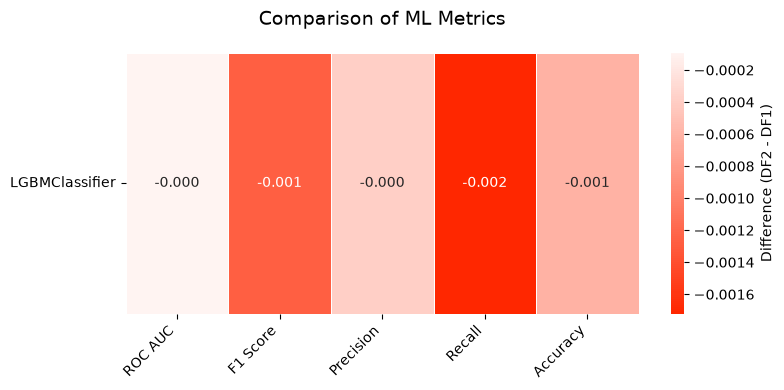

In [110]:
compare_metrics_heatmap(initial_metrics, randomized_search_metrics)

# Bayes Search

In [115]:
param_bayes = {
    "LGBMClassifier__num_leaves": Integer(10, 25),
    "LGBMClassifier__learning_rate": Real(0.01, 0.1, prior='log-uniform'),
    "LGBMClassifier__n_estimators": Integer(100, 1000),
}

In [116]:
bayes_search = BayesSearchCV(
    random_state=SEED,
    estimator=pipeline,
    search_spaces=param_bayes,
    n_iter=100,
    cv=cv,
    scoring='roc_auc',
    optimizer_kwargs={'base_estimator': 'GP'},
    verbose=3,
    n_jobs=1
)

In [117]:
bayes_search_start = timer()
bayes_search.fit(X_train, y_train)
bayes_search_end = timer()

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7479, number of negative: 23779
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 379
[LightGBM] [Info] Number of data points in the train set: 31258, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239267 -> initscore=-1.156704
[LightGBM] [Info] Start training from score -1.156704
[CV 1/5] END LGBMClassifier__learning_rate=0.02571011142608906, LGBMClassifier__n_estimators=755, LGBMClassifier__num_leaves=24;, score=0.929 total time=   1.5s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7479, number of negative: 

In [118]:
print(f"Total time: {bayes_search_end - bayes_search_start:.2f} seconds")

Total time: 691.57 seconds


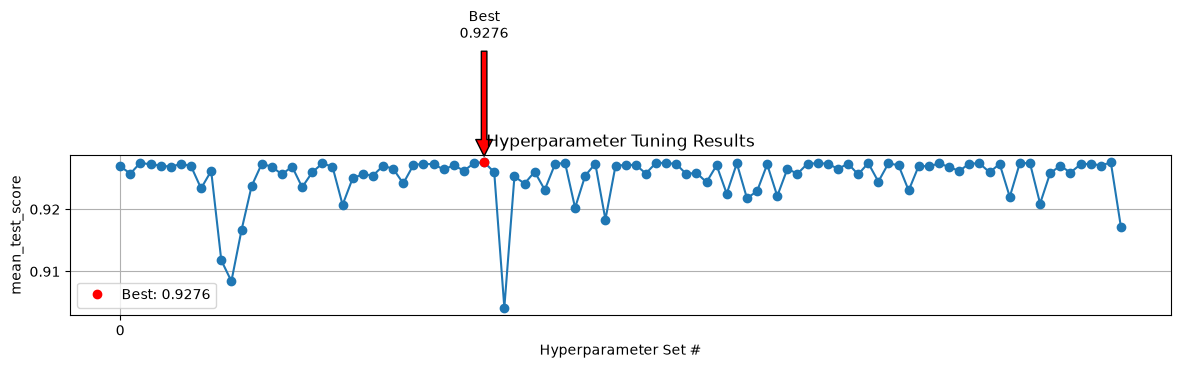

In [119]:
data = plot_hyperparam_search_results(bayes_search.cv_results_, xtick_step=100)

In [120]:
bayes_search.best_params_

OrderedDict([('LGBMClassifier__learning_rate', 0.08302387051093874),
             ('LGBMClassifier__n_estimators', 480),
             ('LGBMClassifier__num_leaves', 10)])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002847 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 392
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685


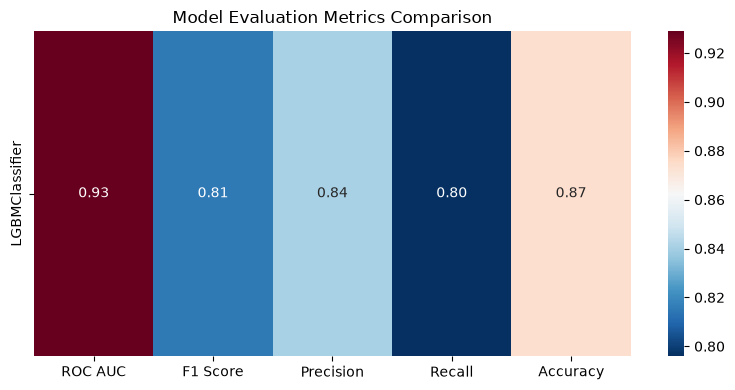

In [121]:
bayes_search_metrics = train_evaluate_models(
    models=[('LGBMClassifier', bayes_search.best_estimator_)],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    seed=SEED
)

In [122]:
bayes_search_metrics

,ROC AUC,F1 Score,Precision,Recall,Accuracy
LGBMClassifier,0.928887,0.814779,0.841033,0.796047,0.873682


(<Figure size 800x400 with 2 Axes>,
                  ROC AUC  F1 Score  Precision    Recall  Accuracy
 LGBMClassifier  0.000179 -0.000138   0.001008 -0.000745  0.000205)

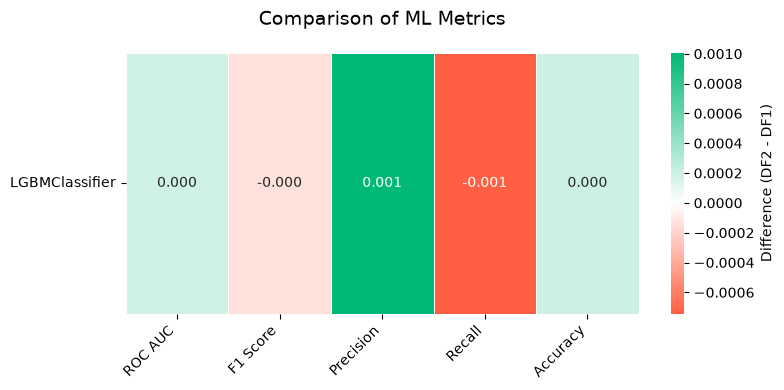

In [123]:
compare_metrics_heatmap(initial_metrics, bayes_search_metrics)

(<Figure size 800x400 with 2 Axes>,
                  ROC AUC  F1 Score  Precision    Recall  Accuracy
 LGBMClassifier -0.000191  0.001327   0.001099  0.001418  0.000819)

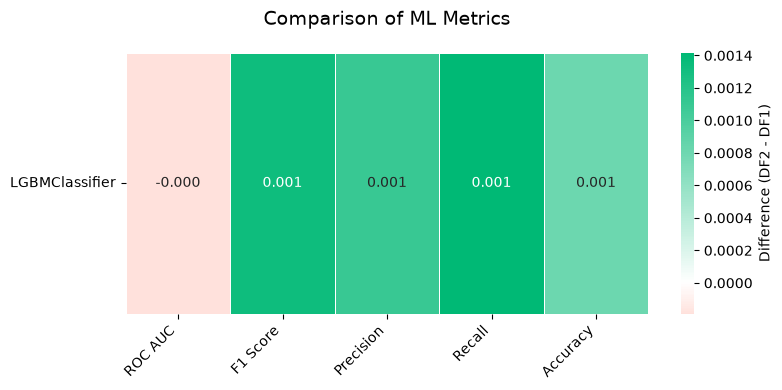

In [124]:
compare_metrics_heatmap(grid_search_metrics, bayes_search_metrics)